# 米筐官方风险因子收益率 — 风格趋势对比

本 notebook 是 [barra_cne5_风格归因.ipynb](barra_cne5_风格归因.ipynb) 的**对照篇**：
那本用自建 Barra CNE5 模型（10 风格）反解因子收益，这本直接调米筐 `rq.get_factor_return()` 拿官方因子收益，然后：

1. **按因子大类分组画累计净值**：直观看到市场风格轮动趋势
2. **对比 v1 / v2 两种模型**：v2 多 6 个因子（质量、股息、反转等），看多了什么视角
3. **与自建 Barra CNE5 对照**：同一时间段，官方 vs 自建的因子累计收益曲线叠加对比
4. **行业因子轮动**：顺便看看这一年哪些行业因子上涨

### 米筐风险因子模型概述

| 模型 | 风格因子数 | 特点 |
|------|-----------|------|
| **v1** | 11 | 经典 Barra CNE5 风格 + comovement（协同运动） |
| **v2** | 17 | 新增盈利质量/投资质量/股息/长期反转/中盘/盈利能力 |
| **v2trd** | — | v2 + 交易类短期因子（需额外权限） |

> ⚠️ **关于 comovement（协同因子）**：它的暴露对所有股票都是 1，反映的是市场系统性上涨而非股票间的风格差异。
> 所以在本 notebook 的走势图中**排除了 comovement**，只画真正刻画横截面差异的风格因子。
> 这不代表 comovement 不重要——分析市场整体收益时心知肚明即可。
> 本 notebook 优先用 **v1 模型**与自建 Barra 对比（因子同名直接映射），再用 **v2 模型**展示更丰富的风格分类视角。

---
## Part 0 · 环境准备

In [43]:
# ==================== Part 0：环境准备 ====================
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 项目根目录
NB_DIR = os.getcwd()
if NB_DIR not in sys.path:
    sys.path.insert(0, NB_DIR)
PROJECT_ROOT = None
for _c in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '../..')]:
    _r = os.path.abspath(_c)
    if os.path.isdir(os.path.join(_r, 'my_utils')):
        PROJECT_ROOT = _r; break
if PROJECT_ROOT is None:
    raise FileNotFoundError('未找到项目根目录')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from my_utils.rqdata import RqData
import rqdatac as rq
RqData()
print('米筐初始化完成')

米筐初始化完成


---
## Part 1 · 获取米筐官方因子收益率

用 `rq.get_factor_return()` 直接拉取米筐风险模型算好的因子日收益序列。

时间区间与 `barra_cne5_风格归因.ipynb` 的 Part 4 对齐：`2025-05-20 ~ 2026-06-18`。

同时拉 v1 和 v2 两套，后面分开画。

In [ ]:
# ==================== Part 1：拉取官方因子收益（增量缓存）====================
from datetime import datetime
import json
from pathlib import Path

WINDOW_START = '2025-05-20'
WINDOW_END   = datetime.now().strftime('%Y-%m-%d')

SAVE_DIR = Path(NB_DIR) / 'saved_data'
SAVE_DIR.mkdir(exist_ok=True)


def _read_meta(meta_path):
    """读取元数据文件，不存在时返回 None。"""
    if not meta_path.exists():
        return None
    try:
        with open(meta_path, 'r') as f:
            return json.load(f)
    except (json.JSONDecodeError, OSError):
        return None


def _write_meta(meta_path, last_date, window_start):
    """写入元数据文件。"""
    meta = {
        'last_date': str(last_date),
        'window_start': str(window_start),
        'created_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    }
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)


def _get_last_date_from_parquet(parquet_path):
    """从 parquet 索引的最后一行为 last_date（元数据缺失时的降级方案）。"""
    try:
        df = pd.read_parquet(parquet_path)
        if len(df) == 0:
            return None
        return df.index[-1]
    except Exception:
        return None


def load_factor_return_with_cache(model, start_date, end_date):
    """带增量缓存的因子收益加载。

    优先用本地缓存，自动增量补充缺失交易日，避免每次全量拉取。
    支持旧版无 meta 的缓存自动过渡，所有异常降级为全量重拉。
    """
    parquet_path = SAVE_DIR / f'rq_factor_return_{model}.parquet'
    meta_path    = SAVE_DIR / f'rq_factor_return_{model}_meta.json'

    end = pd.Timestamp(end_date)

    # ---- 情况 1：缓存存在 + meta 存在 → 比对日期做增量 ----
    if parquet_path.exists() and meta_path.exists():
        meta = _read_meta(meta_path)
        if meta is not None:
            last = pd.Timestamp(meta['last_date'])
            wstart = meta.get('window_start')

            # 如果 window_start 变了 → 全量重拉
            if wstart != start_date:
                print(f'[缓存] 起始日期变化（{wstart} → {start_date}），全量重拉')
                fr = rq.get_factor_return(start_date, end_date, model=model, method='implicit')
                _write_meta(meta_path, last_date=end_date, window_start=start_date)
                fr.to_parquet(parquet_path)
                print(f'[缓存] 全量拉取完成：{fr.shape}')
                return fr

            if last >= end:
                # 缓存已覆盖目标日期，直接加载
                fr = pd.read_parquet(parquet_path)
                print(f'[缓存] 已最新（{last.strftime("%Y-%m-%d")}），跳过拉取')
                return fr
            else:
                # 增量拉取缺失区间
                next_date = (last + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
                print(f'[缓存] 增量拉取 {next_date} ~ {end_date}')
                fr = pd.read_parquet(parquet_path)
                new_data = rq.get_factor_return(next_date, end_date, model=model, method='implicit')
                if new_data is not None and len(new_data) > 0:
                    fr = pd.concat([fr, new_data])
                    _write_meta(meta_path, last_date=end_date, window_start=start_date)
                    fr.to_parquet(parquet_path)
                    print(f'[缓存] 增量追加 {len(new_data)} 条，共 {len(fr)} 条')
                else:
                    print(f'[缓存] 增量区间无新数据')
                return fr

    # ---- 情况 2：parquet 存在但 meta 不存在（旧版缓存过渡）----
    if parquet_path.exists() and not meta_path.exists():
        print(f'[缓存] 检测到旧版缓存，重建元数据...')
        last_date = _get_last_date_from_parquet(parquet_path)
        if last_date is not None:
            _write_meta(meta_path, last_date=last_date.strftime('%Y-%m-%d'), window_start=start_date)
            # 重建 meta 后，重新走情况 1 的逻辑
            return load_factor_return_with_cache(model, start_date, end_date)

    # ---- 情况 3：缓存不存在 → 全量拉取 ----
    print(f'[缓存] 缓存不存在，全量拉取...')
    try:
        fr = rq.get_factor_return(start_date, end_date, model=model, method='implicit')
        _write_meta(meta_path, last_date=end_date, window_start=start_date)
        fr.to_parquet(parquet_path)
        print(f'[缓存] 全量拉取完成：{fr.shape}')
        return fr
    except Exception as e:
        print(f'[缓存] 全量拉取失败: {e}')
        raise


# ---- 实际加载 v1 / v2 ----
try:
    fr_v1 = load_factor_return_with_cache('v1', WINDOW_START, WINDOW_END)
    fr_v2 = load_factor_return_with_cache('v2', WINDOW_START, WINDOW_END)
except Exception as e:
    print(f'因子收益拉取失败，请检查网络或米筐权限: {e}')
    raise

# 提取风格因子列表（行业因子是中文名，风格因子是英文小写名）
rq_style_v1 = [c for c in fr_v1.columns if c.isascii() and c.islower()]
rq_style_v2 = [c for c in fr_v2.columns if c.isascii() and c.islower()]

# comovement 因子暴露恒为 1，它反映的是系统市场上涨而非"风格趋势"，
# 后续画图时排除它，只保留真正刻画横截面差异的风格因子。
# 在心知肚明 comovement 的前提下看风格相对收益更清晰。
STYLE_V1_NO_COMM = [s for s in rq_style_v1 if s != 'comovement']
STYLE_V2_NO_COMM = [s for s in rq_style_v2 if s != 'comovement']
print(f'\nv1 画图用风格因子 ({len(STYLE_V1_NO_COMM)})：{STYLE_V1_NO_COMM}')
print(f'v2 画图用风格因子 ({len(STYLE_V2_NO_COMM)})：{STYLE_V2_NO_COMM}')
print(f'(已排除 comovement——它暴露恒为 1，反映系统性市场收益而非风格差异)')

## Part 2 · 投资者风格雷达（v2 显式风格因子）

这一部分是主看板：只看 v2 显式风格因子，不把 `comovement` 和行业因子混进风格排名。

读图口径：

- 因子收益为正：高暴露方向跑赢低暴露方向。
- 因子收益为负：低暴露方向跑赢高暴露方向。
- `comovement` 单独作为市场整体温度，不代表风格分化。


In [ ]:
# ==================== 投资者风格雷达：v2 显式风格因子 ====================
from rq_style_dashboard import (
    build_factor_direction_table,
    build_style_performance_table,
    generate_market_style_commentary,
    plot_key_style_groups,
    plot_market_temperature,
    plot_style_heatmap,
    plot_style_rank_bar,
    select_explicit_style_factors,
)

# 主看板只看有明确正负方向解释的显式风格因子。
# 这一步会自然排除中文行业因子、comovement 和暂未写入口径字典的列。
PRIMARY_MODEL = 'v2'
STYLE_WINDOWS = (20, 60, 120)
DASHBOARD_LOOKBACK_FOR_RANK = 60
PRIMARY_STYLE_FACTORS = select_explicit_style_factors(fr_v2.columns)

missing_from_v2 = [factor for factor in PRIMARY_STYLE_FACTORS if factor not in fr_v2.columns]
if missing_from_v2:
    print(f'以下风格因子在 v2 数据中缺失，将不会进入看板: {missing_from_v2}')

print(f'主看板使用 v2 显式风格因子 ({len(PRIMARY_STYLE_FACTORS)}): {PRIMARY_STYLE_FACTORS}')
print(f'数据区间: {fr_v2.index.min().date()} ~ {fr_v2.index.max().date()}，样本 {len(fr_v2)} 个交易日')

style_perf_table = build_style_performance_table(
    fr_v2,
    PRIMARY_STYLE_FACTORS,
    windows=STYLE_WINDOWS,
    rank_window=DASHBOARD_LOOKBACK_FOR_RANK,
)

direction_table = build_factor_direction_table(
    PRIMARY_STYLE_FACTORS,
    latest_returns=style_perf_table['60日收益%'].div(100) if '60日收益%' in style_perf_table.columns else None,
)

print('\n=== 因子方向解释表（先看这个，再看图）===')
display(direction_table)

print('\n=== 显式风格因子表现总览（默认按60日收益排序）===')
display(style_perf_table.style.format({
    col: '{:+.2f}' for col in style_perf_table.columns if col.endswith('收益%')
}))

print('\n=== 自动市场风格结论 ===')
print(generate_market_style_commentary(style_perf_table))


In [ ]:
# ==================== 投资者风格雷达图表 ====================
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

plot_style_heatmap(style_perf_table, ax=axes[0, 0])
plot_style_rank_bar(style_perf_table, rank_col='60日收益%', ax=axes[0, 1])
plot_key_style_groups(fr_v2[PRIMARY_STYLE_FACTORS], ax=axes[1, 0])
plot_market_temperature(fr_v2, ax=axes[1, 1])

plt.tight_layout()
plt.show()


### 因子大类映射

把细颗粒的单个风格因子归到几个**经济含义大类**，按大类画累计净值——一眼看清"市场风格趋势"。

In [45]:
# ==================== 因子大类映射 ====================
# v1 模型 10 个风格因子（已排除 comovement）→ 7 个大类
CATEGORY_MAP_V1 = {
    '规模 (Size)':       ['size', 'non_linear_size'],
    '价值 (Value)':      ['book_to_price', 'earnings_yield'],
    '成长 (Growth)':     ['growth'],
    '动量 (Momentum)':   ['momentum'],
    '流动性 (Liquidity)': ['liquidity'],
    '风险 (Risk)':       ['beta', 'residual_volatility'],
    '杠杆 (Leverage)':   ['leverage'],
}

# v2 模型 16 个风格因子（已排除 comovement）→ 9 个大类
CATEGORY_MAP_V2 = {
    '规模 (Size)':         ['size', 'mid_cap', 'non_linear_size'],
    '价值 (Value)':        ['book_to_price', 'earnings_yield', 'dividend_yield'],
    '成长 (Growth)':       ['growth'],
    '动量 (Momentum)':     ['momentum', 'longterm_reversal'],
    '流动性 (Liquidity)':   ['liquidity'],
    '风险 (Risk)':         ['beta', 'residual_volatility'],
    '杠杆 (Leverage)':     ['leverage'],
    '质量 (Quality)':      ['profitability', 'investment_quality', 'earnings_quality'],
    '盈利波动 (Earn.Var.)': ['earnings_variability'],
}

# 大类颜色方案
CATEGORY_COLORS = {
    '规模 (Size)':         '#1f77b4',
    '价值 (Value)':        '#2ca02c',
    '成长 (Growth)':       '#9467bd',
    '动量 (Momentum)':     '#d62728',
    '流动性 (Liquidity)':  '#ff7f0e',
    '风险 (Risk)':         '#8c564b',
    '杠杆 (Leverage)':     '#e377c2',
    '质量 (Quality)':      '#17becf',
    '盈利波动 (Earn.Var.)': '#bcbd22',
}

print('v1 大类映射：')
for cat, facs in CATEGORY_MAP_V1.items():
    print(f'  {cat}: {facs}')
print(f'\nv2 额外大类：质量、盈利波动')
for cat, facs in CATEGORY_MAP_V2.items():
    if cat not in CATEGORY_MAP_V1:
        print(f'  {cat}: {facs}')
print(f'\n注：comovement 已被排除（暴露恒为 1，反映系统市场收益而非风格差异）')

v1 大类映射：
  规模 (Size): ['size', 'non_linear_size']
  价值 (Value): ['book_to_price', 'earnings_yield']
  成长 (Growth): ['growth']
  动量 (Momentum): ['momentum']
  流动性 (Liquidity): ['liquidity']
  风险 (Risk): ['beta', 'residual_volatility']
  杠杆 (Leverage): ['leverage']

v2 额外大类：质量、盈利波动
  质量 (Quality): ['profitability', 'investment_quality', 'earnings_quality']
  盈利波动 (Earn.Var.): ['earnings_variability']

注：comovement 已被排除（暴露恒为 1，反映系统市场收益而非风格差异）


## 研究附录 · 原始风格趋势、v1/v2 对照与行业因子

以下内容保留原 notebook 的研究视角：v1/v2 对比、自建 Barra 对照、大类聚合和行业因子轮动。日常看市场风格时，优先使用上方“投资者风格雷达”。


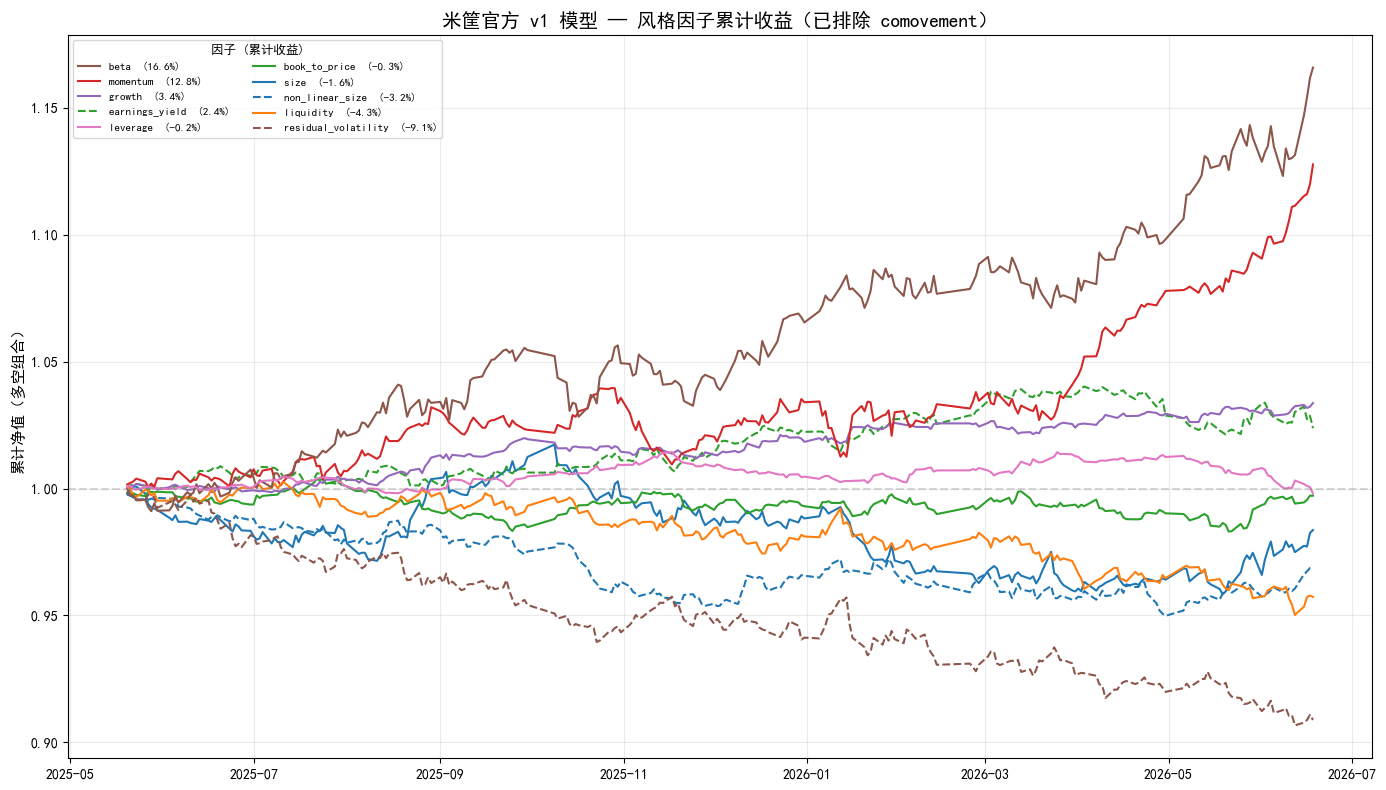

=== 风格因子累计收益（2025-05-20 ~ 2026-06-18）===
注：comovement 已排除（暴露恒为 1，反映系统市场收益而非风格差异）
                     累计收益%  年化收益%  年化波动%      IR
factor                                          
beta                 16.59  14.85   6.24  2.3813
momentum             12.78  11.58   4.48  2.5858
growth                3.37   3.18   1.53  2.0773
earnings_yield        2.38   2.28   2.69  0.8470
leverage             -0.20  -0.18   1.44 -0.1273
book_to_price        -0.29  -0.25   2.11 -0.1188
size                 -1.64  -1.48   4.32 -0.3435
non_linear_size      -3.16  -3.02   2.90 -1.0400
liquidity            -4.27  -4.12   3.20 -1.2859
residual_volatility  -9.12  -9.05   4.09 -2.2101


In [46]:
# ==================== Part 2：v1 模型风格因子累计收益 ====================
def plot_style_by_category(fr, style_factors, cat_map, title, figsize=(14, 8)):
    """按因子大类分组画累计收益，大类间不同色，大类内同色不同线型。"""
    cum = (1 + fr[style_factors]).cumprod()
    
    fig, ax = plt.subplots(figsize=figsize)
    linestyles = ['-', '--', '-.', ':']
    
    final_ret = cum.iloc[-1]
    
    for cat, facs in cat_map.items():
        color = CATEGORY_COLORS.get(cat, '#333333')
        for i, f in enumerate(facs):
            if f not in cum.columns:
                continue
            ls = linestyles[i % len(linestyles)]
            ax.plot(cum.index, cum[f], color=color, linestyle=ls,
                    linewidth=1.5, label=f'{f}')
    
    ax.axhline(1, color='gray', ls='--', alpha=0.3)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('累计净值（多空组合）', fontsize=11)
    ax.grid(True, alpha=0.25)
    
    # 图例：按最终收益排序
    handles, labels = ax.get_legend_handles_labels()
    order = sorted(zip(handles, labels), key=lambda x: final_ret.get(x[1], 1), reverse=True)
    handles_sorted, labels_sorted = zip(*order)
    legend = ax.legend(handles_sorted, [f'{l}  ({final_ret.get(l, 1)-1:.1%})' for l in labels_sorted],
                       ncol=2, fontsize=8, loc='upper left')
    legend.set_title('因子 (累计收益)', prop={'size': 9})
    
    plt.tight_layout()
    plt.show()
    
    # 打印数值总结
    print(f'=== 风格因子累计收益（{fr.index[0].strftime("%Y-%m-%d")} ~ {fr.index[-1].strftime("%Y-%m-%d")}）===')
    print('注：comovement 已排除（暴露恒为 1，反映系统市场收益而非风格差异）')
    summary = pd.DataFrame({
        '累计收益': final_ret - 1,
        '年化收益': fr[style_factors].mean() * 252,
        '年化波动': fr[style_factors].std() * np.sqrt(252),
        'IR': fr[style_factors].mean() / fr[style_factors].std() * np.sqrt(252),
    }).sort_values('累计收益', ascending=False).round(4)
    summary['累计收益%'] = summary['累计收益'] * 100
    summary['年化收益%'] = summary['年化收益'] * 100
    summary['年化波动%'] = summary['年化波动'] * 100
    print(summary[['累计收益%', '年化收益%', '年化波动%', 'IR']].to_string())
    return cum


cum_v1 = plot_style_by_category(fr_v1, STYLE_V1_NO_COMM, CATEGORY_MAP_V1,
                                '米筐官方 v1 模型 — 风格因子累计收益（已排除 comovement）')

### 按大类合计画柱状图

把每个大类内的因子累计收益等权平均（或取中位数），画大类级别的累计净值，更宏观。

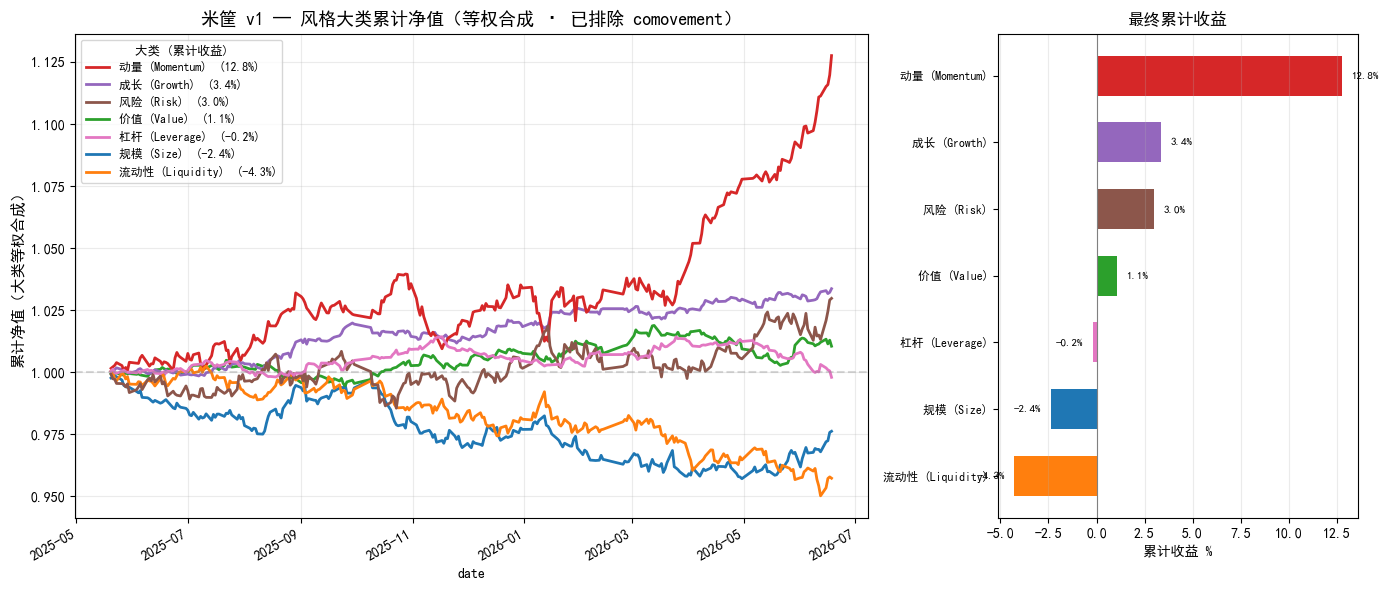

In [47]:
# ==================== 大类级别的累计净值（等权合成）====================
def plot_category_aggregate(fr, style_factors, cat_map, title, figsize=(14, 6)):
    """按大类等权合成因子收益，画大类累计净值。"""
    cat_ret = pd.DataFrame(index=fr.index)
    for cat, facs in cat_map.items():
        available = [f for f in facs if f in fr.columns]
        if not available:
            continue
        cat_ret[cat] = fr[available].mean(axis=1)
    
    cat_cum = (1 + cat_ret).cumprod()
    
    fig, axes = plt.subplots(1, 2, figsize=figsize, gridspec_kw={'width_ratios': [2.2, 1]})
    
    # 左：累计净值图
    ax = axes[0]
    colors_cat = [CATEGORY_COLORS.get(c, '#333') for c in cat_cum.columns]
    cat_cum.plot(ax=ax, color=colors_cat, linewidth=2.0, legend=False)
    ax.axhline(1, color='gray', ls='--', alpha=0.3)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('累计净值（大类等权合成）', fontsize=11)
    ax.grid(True, alpha=0.25)
    
    # 图例：按最终收益排序
    final_vals = cat_cum.iloc[-1]
    handles, labels = ax.get_legend_handles_labels()
    order = sorted(zip(handles, labels), key=lambda x: final_vals.get(x[1], 1), reverse=True)
    handles_sorted, labels_sorted = zip(*order)
    legend = ax.legend(handles_sorted,
                       [f'{l}  ({final_vals.get(l, 1)-1:.1%})' for l in labels_sorted],
                       ncol=1, fontsize=8.5, loc='upper left')
    legend.set_title('大类 (累计收益)', prop={'size': 9})
    
    # 右：最终累计收益柱状图
    ax = axes[1]
    ret_sorted = (final_vals - 1).sort_values()
    colors_bar = [CATEGORY_COLORS.get(c, '#333') for c in ret_sorted.index]
    bars = ax.barh(range(len(ret_sorted)), ret_sorted.values * 100, color=colors_bar, height=0.6)
    ax.set_yticks(range(len(ret_sorted)))
    ax.set_yticklabels(ret_sorted.index, fontsize=8.5)
    ax.axvline(0, color='gray', lw=0.8)
    ax.set_xlabel('累计收益 %')
    ax.set_title('最终累计收益', fontsize=12)
    ax.grid(True, alpha=0.25, axis='x')
    for bar, val in zip(bars, ret_sorted.values * 100):
        ax.text(val + (0.5 if val >= 0 else -0.5), bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', ha='left' if val >= 0 else 'right', va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    return cat_ret, cat_cum


cat_ret_v1, cat_cum_v1 = plot_category_aggregate(
    fr_v1, STYLE_V1_NO_COMM, CATEGORY_MAP_V1,
    '米筐 v1 — 风格大类累计净值（等权合成 · 已排除 comovement）')

## Part 3 · v2 模型风格趋势（更丰富的大类划分）

v2 模型多了 6 个因子，可以分出更多有经济意义的大类（同样排除了 comovement）：

- **质量 (Quality)**：`profitability` + `investment_quality` + `earnings_quality` —— 好公司的特质
- **股息 (Dividend)**：`dividend_yield` —— 高股息风格
- **长期反转 (Reversal)**：`longterm_reversal` —— 过去跌多的会反弹？
- **中盘 (Mid-cap)**：`mid_cap` —— 中盘股 vs 大盘/小盘
- **盈利波动 (Earn.Var.)**：`earnings_variability` —— 盈利稳定的公司更受青睐？

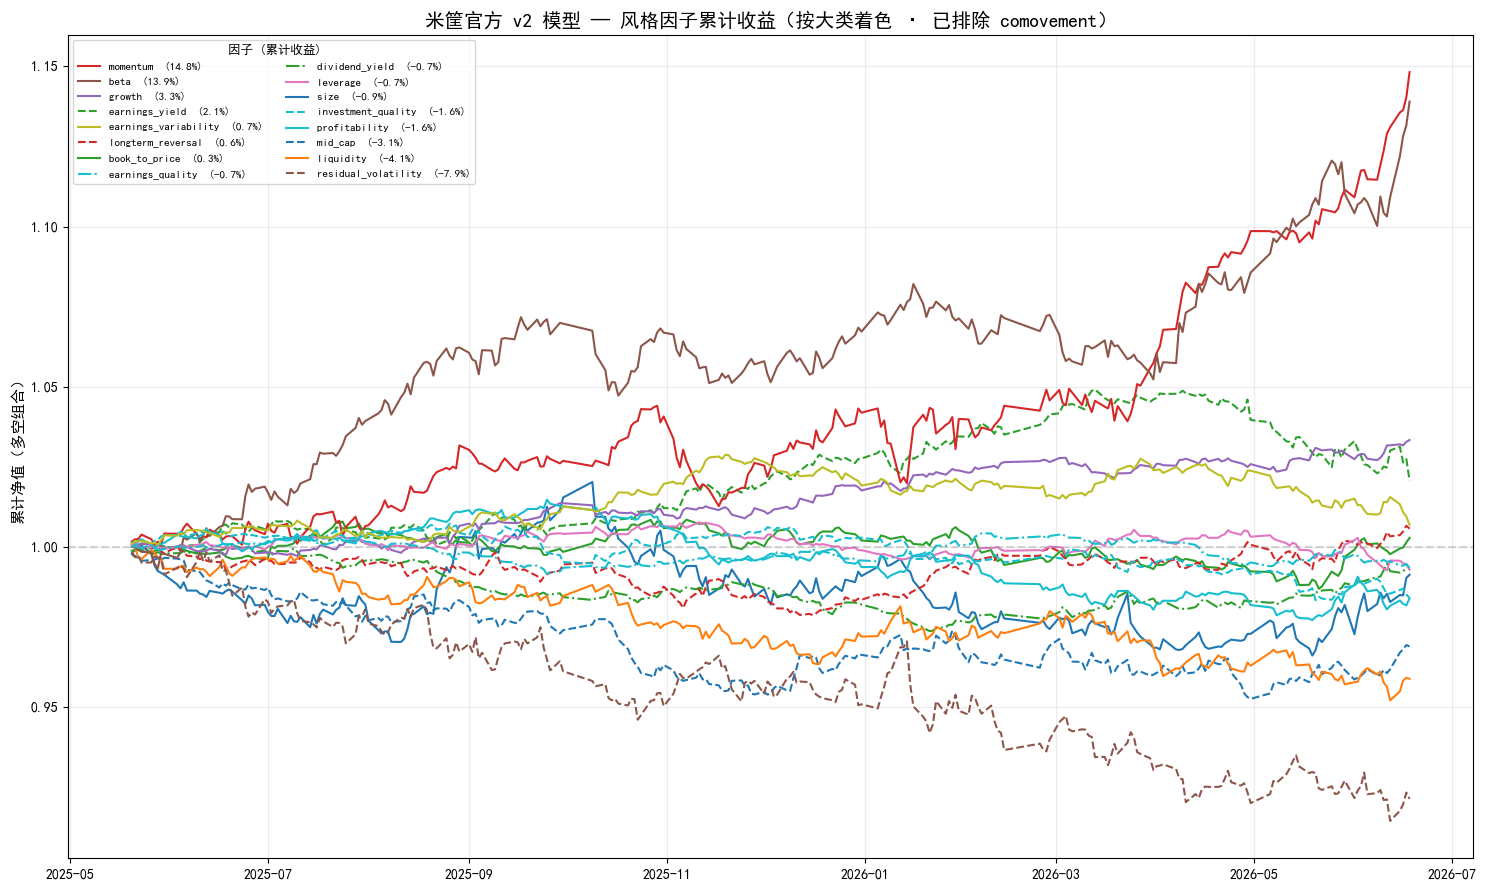

=== 风格因子累计收益（2025-05-20 ~ 2026-06-18）===
注：comovement 已排除（暴露恒为 1，反映系统市场收益而非风格差异）
                      累计收益%  年化收益%  年化波动%      IR
factor                                           
momentum              14.82  13.31   4.65  2.8645
beta                  13.90  12.56   5.13  2.4481
growth                 3.34   3.14   1.45  2.1647
earnings_yield         2.06   1.98   2.59  0.7670
earnings_variability   0.68   0.67   1.86  0.3586
longterm_reversal      0.56   0.56   2.04  0.2731
book_to_price          0.28   0.28   1.94  0.1462
earnings_quality      -0.66  -0.63   1.11 -0.5678
dividend_yield        -0.68  -0.64   1.34 -0.4776
leverage              -0.71  -0.67   1.35 -0.4986
size                  -0.88  -0.74   4.47 -0.1657
investment_quality    -1.60  -1.52   1.63 -0.9331
profitability         -1.61  -1.53   1.89 -0.8108
mid_cap               -3.11  -2.98   2.84 -1.0480
liquidity             -4.12  -3.97   3.06 -1.3000
residual_volatility   -7.87  -7.70   5.09 -1.5117


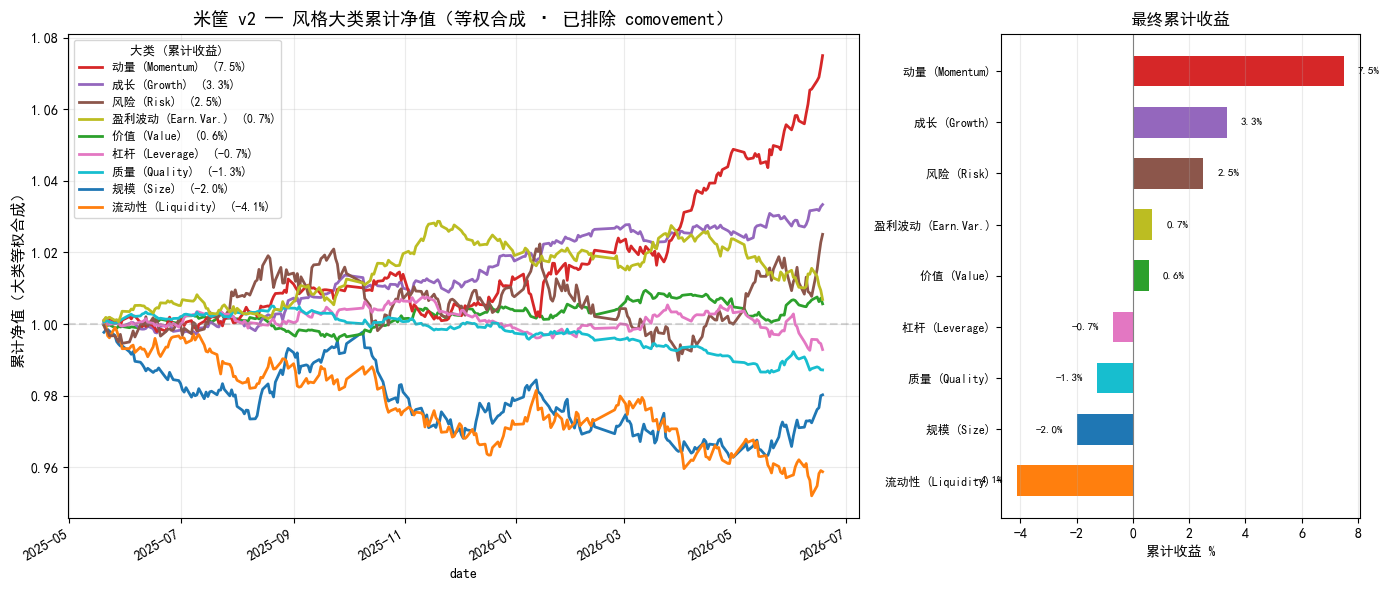

In [48]:
# ==================== Part 3：v2 模型风格趋势 ====================
cum_v2 = plot_style_by_category(fr_v2, STYLE_V2_NO_COMM, CATEGORY_MAP_V2,
                                '米筐官方 v2 模型 — 风格因子累计收益（按大类着色 · 已排除 comovement）',
                                figsize=(15, 9))

cat_ret_v2, cat_cum_v2 = plot_category_aggregate(
    fr_v2, STYLE_V2_NO_COMM, CATEGORY_MAP_V2,
    '米筐 v2 — 风格大类累计净值（等权合成 · 已排除 comovement）')

---
## Part 4 · 与自建 Barra CNE5 对比

关键对比：

1. **米筐官方 vs 自建**：同一个 10 风格因子（v1 去掉 comovement），画叠加累计收益
2. **相关性矩阵**：官方因子收益序列 vs 自建因子收益序列的相关系数
3. **差异归因**：哪些因子方向一致（>0.7），哪些有分歧（<0.5）——口径差异分析

> ⚠️ 自建 Barra 结果需要先运行 `barra_cne5_风格归因.ipynb` 的 Part 1~4 得到 `style_ret` 变量（自建因子收益序列）。如果未运行过，本 Part 会跳过对比，仅展示官方结果。

In [49]:
# ==================== Part 4：与自建 Barra CNE5 对比 ====================
# 加载自建 Barra CNE5 的因子收益序列，优先级：
#   1. 内存变量 style_ret（和 barra_cne5_风格归因.ipynb 同会话运行）
#   2. 预存 parquet 文件 saved_data/self_built_style_ret.parquet

SELF_AVAILABLE = False
self_style_ret = None

# 优先 1：内存变量（同会话）
try:
    self_style_ret = style_ret
    SELF_AVAILABLE = True
    print(f'从当前会话加载自建 Barra CNE5 因子收益：{self_style_ret.shape}')
except NameError:
    pass

# 优先 2：预存文件
if not SELF_AVAILABLE:
    _parquet_paths = [
        os.path.join(NB_DIR, 'saved_data', 'self_built_style_ret.parquet'),
        os.path.join(PROJECT_ROOT, '因子回测', 'learn', 'saved_data', 'self_built_style_ret.parquet'),
    ]
    for _p in _parquet_paths:
        if os.path.exists(_p):
            self_style_ret = pd.read_parquet(_p)
            SELF_AVAILABLE = True
            print(f'从文件加载自建 Barra CNE5 因子收益：{self_style_ret.shape}')
            break

if not SELF_AVAILABLE:
    print('未找到自建 Barra CNE5 因子收益数据，跳过对比。')
    print('如需对比，有两种方式：')
    print('  (1) 先运行 barra_cne5_风格归因.ipynb 的 Part 1~4，再回来运行本 notebook（同一内核）')
    print('  (2) 运行下方"保存自建数据"代码块，先导出自建结果为 parquet')

未找到自建 Barra CNE5 因子收益数据，跳过对比。
如需对比，有两种方式：
  (1) 先运行 barra_cne5_风格归因.ipynb 的 Part 1~4，再回来运行本 notebook（同一内核）
  (2) 运行下方"保存自建数据"代码块，先导出自建结果为 parquet


### Part 4a · 叠加累计收益曲线对比

同一因子，官方（实线）vs 自建（虚线）的累计收益叠加在同一张图上——
方向一致且幅度接近 = 自建质量高；方向一致但幅度差异 = 口径细节差异；方向不一致 = 需排查。

In [50]:
# ==================== Part 4a：叠加累计收益对比 ====================
if SELF_AVAILABLE:
    # 自建因子序列与官方 v1 的共有因子
    common_styles = [s for s in ['size', 'beta', 'momentum', 'residual_volatility',
                                 'non_linear_size', 'book_to_price', 'liquidity',
                                 'earnings_yield', 'growth', 'leverage']
                    if s in self_style_ret.columns and s in fr_v1.columns]
    
    # 对齐日期：取两者的交集
    # 自建的结果可能存在缺某些交易日的截面回归失败
    common_dates = self_style_ret.index.intersection(fr_v1.index)
    
    n_styles = len(common_styles)
    n_cols = 3
    n_rows = (n_styles + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
    axes = axes.flatten()
    
    for i, s in enumerate(common_styles):
        ax = axes[i]
        # 官方（实线）
        off_cum = (1 + fr_v1.loc[common_dates, s]).cumprod()
        ax.plot(off_cum.index, off_cum.values, 'b-', linewidth=1.8, label=f'官方 v1')
        # 自建（虚线）
        self_cum = (1 + self_style_ret.loc[common_dates, s]).cumprod()
        ax.plot(self_cum.index, self_cum.values, 'r--', linewidth=1.5, label=f'自建')
        
        # 相关性标注
        corr_val = fr_v1.loc[common_dates, s].corr(self_style_ret.loc[common_dates, s])
        ax.set_title(f'{s}  (ρ={corr_val:.2f})', fontsize=10, fontweight='bold')
        ax.axhline(1, color='gray', ls=':', alpha=0.3)
        ax.grid(True, alpha=0.2)
        ax.legend(fontsize=7, loc='best')
    
    # 隐藏多余子图
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle('自建 Barra CNE5 vs 米筐官方 v1 — 风格因子累计收益逐因子对比',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # 打印相关性总结
    corr_summary = pd.Series({
        s: fr_v1.loc[common_dates, s].corr(self_style_ret.loc[common_dates, s])
        for s in common_styles
    }).sort_values(ascending=False)
    print('=== 官方 vs 自建因子收益序列相关系数（时间序列相关）===')
    print(corr_summary.round(3).to_string())
    print(f'\n> 0.7 = 高度一致；0.4~0.7 = 方向一致但幅度差异；< 0.4 = 差异较大')
else:
    print('跳过对比（无自建数据）。请先运行 barra_cne5_风格归因.ipynb 的 Part 1~4。')

跳过对比（无自建数据）。请先运行 barra_cne5_风格归因.ipynb 的 Part 1~4。


### Part 4b · 收益相关性热图

把所有官方 v1 风格因子 + 自建因子的收益序列合并，算相关系数矩阵热图——
对角线上是同因子交叉相关，对角线外是不同因子间的联动。理想情况：同因子交叉相关 > 0.5 且高于与其他因子的相关。

In [51]:
# ==================== Part 4b：收益相关性热图 ====================
if SELF_AVAILABLE:
    # 合并官方和自建的因子收益
    common_dates = self_style_ret.index.intersection(fr_v1.index)
    merged = pd.DataFrame({
        **{f'官方_{s}': fr_v1.loc[common_dates, s] for s in common_styles},
        **{f'自建_{s}': self_style_ret.loc[common_dates, s] for s in common_styles},
    })
    
    corr_mat = merged.corr()
    
    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(corr_mat.values, cmap='RdBu_r', vmin=-0.5, vmax=1.0)
    
    # 标签
    labels = corr_mat.columns
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7.5)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=7.5)
    
    # 在矩阵上画数值
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f'{corr_mat.iloc[i, j]:.2f}',
                    ha='center', va='center', fontsize=5.5,
                    color='white' if abs(corr_mat.iloc[i, j]) > 0.6 else 'black')
    
    # 画分隔线：把官方 vs 自建分开
    sep = len(common_styles)
    ax.axhline(sep - 0.5, color='black', linewidth=1.5)
    ax.axvline(sep - 0.5, color='black', linewidth=1.5)
    
    ax.set_title('官方 v1 vs 自建 Barra — 因子收益相关系数矩阵', fontsize=13, fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()
    
    # 提取"同因子自建 vs 官方"的对角线
    diag_corr = pd.Series({s: corr_mat.loc[f'官方_{s}', f'自建_{s}'] for s in common_styles}).sort_values()
    print('=== 同因子官方 vs 自建 时间序列相关系数（排序）===')
    print(diag_corr.round(3).to_string())

---
## Part 5 · 行业因子趋势（补充视角）

因子收益率不止风格因子，还有行业因子。画行业累计收益——
"这一年哪些行业在赚钱"。作为风格分析的补充。

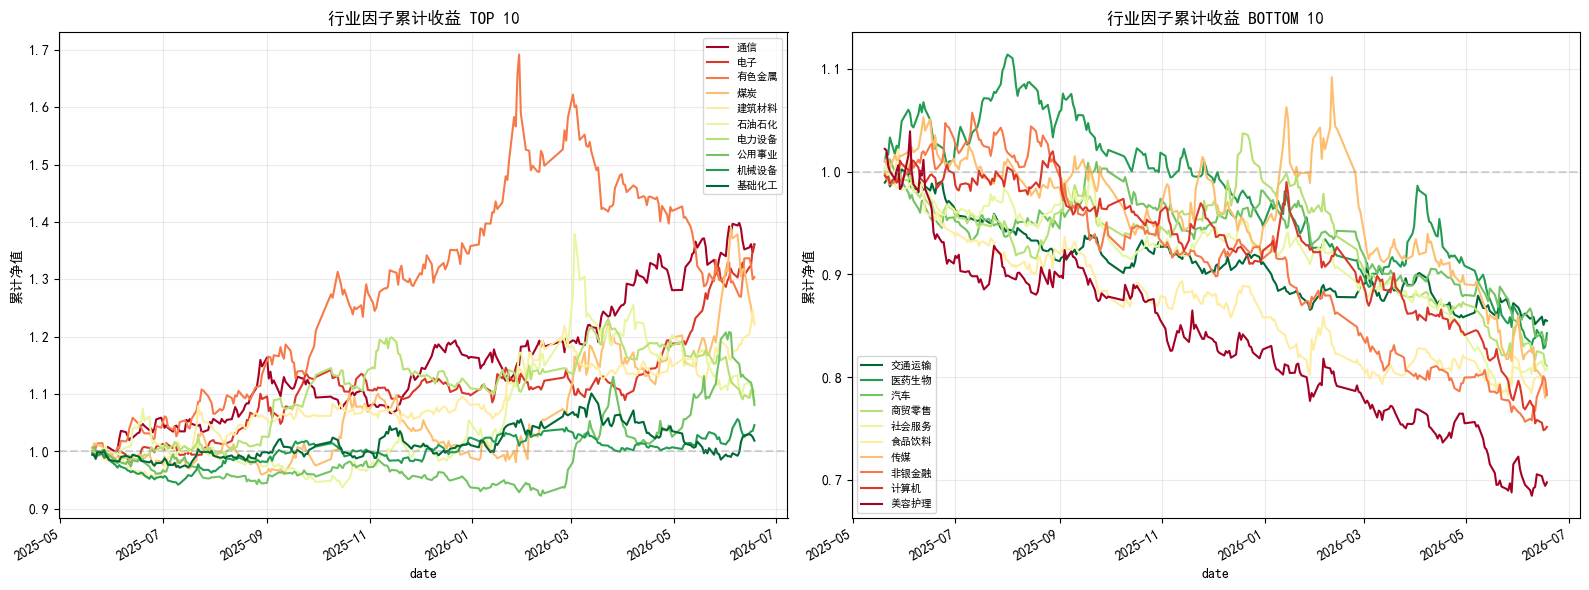

=== 行业因子累计收益（2025-05-20 ~ 2026-06-18）===
factor
通信      36.11%
电子      36.00%
有色金属    30.36%
煤炭      22.48%
建筑材料    22.03%
石油石化    10.51%
电力设备     8.81%
公用事业     8.09%
机械设备     4.58%
基础化工     1.87%
综合       0.33%
银行      -2.04%
建筑装饰    -6.39%
国防军工    -8.20%
轻工制造    -8.75%
环保      -9.20%
房地产     -9.63%
纺织服饰    -9.66%
钢铁     -11.96%
家用电器   -12.15%
农林牧渔   -14.33%
交通运输   -14.54%
医药生物   -15.75%
汽车     -16.34%
商贸零售   -18.91%
社会服务   -19.15%
食品饮料   -21.26%
传媒     -21.41%
非银金融   -21.76%
计算机    -24.86%
美容护理   -30.26%


In [52]:
# ==================== Part 5：行业因子累计收益 ====================
industry_cols_v1 = [c for c in fr_v1.columns if not c.isascii() or not c.islower()]
# 实际上行业因子是中文名
industry_cols_v1 = [c for c in fr_v1.columns if not all(c.isascii() for c in str(c))]

if len(industry_cols_v1) > 0:
    ind_cum = (1 + fr_v1[industry_cols_v1]).cumprod()
    
    # 按最终收益排序，取前 10 和后 10
    final_sort = ind_cum.iloc[-1].sort_values(ascending=False)
    top10 = final_sort.head(10)
    bottom10 = final_sort.tail(10)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 左：涨幅前 10 行业
    ax = axes[0]
    ind_cum[top10.index].plot(ax=ax, linewidth=1.5, colormap='RdYlGn')
    ax.axhline(1, color='gray', ls='--', alpha=0.3)
    ax.set_title('行业因子累计收益 TOP 10', fontsize=12, fontweight='bold')
    ax.set_ylabel('累计净值'); ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7.5, ncol=1)
    
    # 右：涨幅后 10 行业
    ax = axes[1]
    ind_cum[bottom10.index].plot(ax=ax, linewidth=1.5, colormap='RdYlGn_r')
    ax.axhline(1, color='gray', ls='--', alpha=0.3)
    ax.set_title('行业因子累计收益 BOTTOM 10', fontsize=12, fontweight='bold')
    ax.set_ylabel('累计净值'); ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7.5, ncol=1)
    
    plt.tight_layout(); plt.show()
    
    print(f'=== 行业因子累计收益（{fr_v1.index[0].strftime("%Y-%m-%d")} ~ {fr_v1.index[-1].strftime("%Y-%m-%d")}）===')
    print(final_sort.to_string(float_format=lambda x: f'{x-1:.2%}'))
else:
    print('未找到行业因子列')

---
## Part 6 · 滚动窗口分析（12 周滚动收益）

静态的累计收益只看到"结果"，滚动窗口能看"趋势变化"：
- 某风格在窗口末期突然切换？
- 各风格是同步涨跌还是此消彼长？

画 12 周（约 60 交易日）滚动累计收益的热力图。

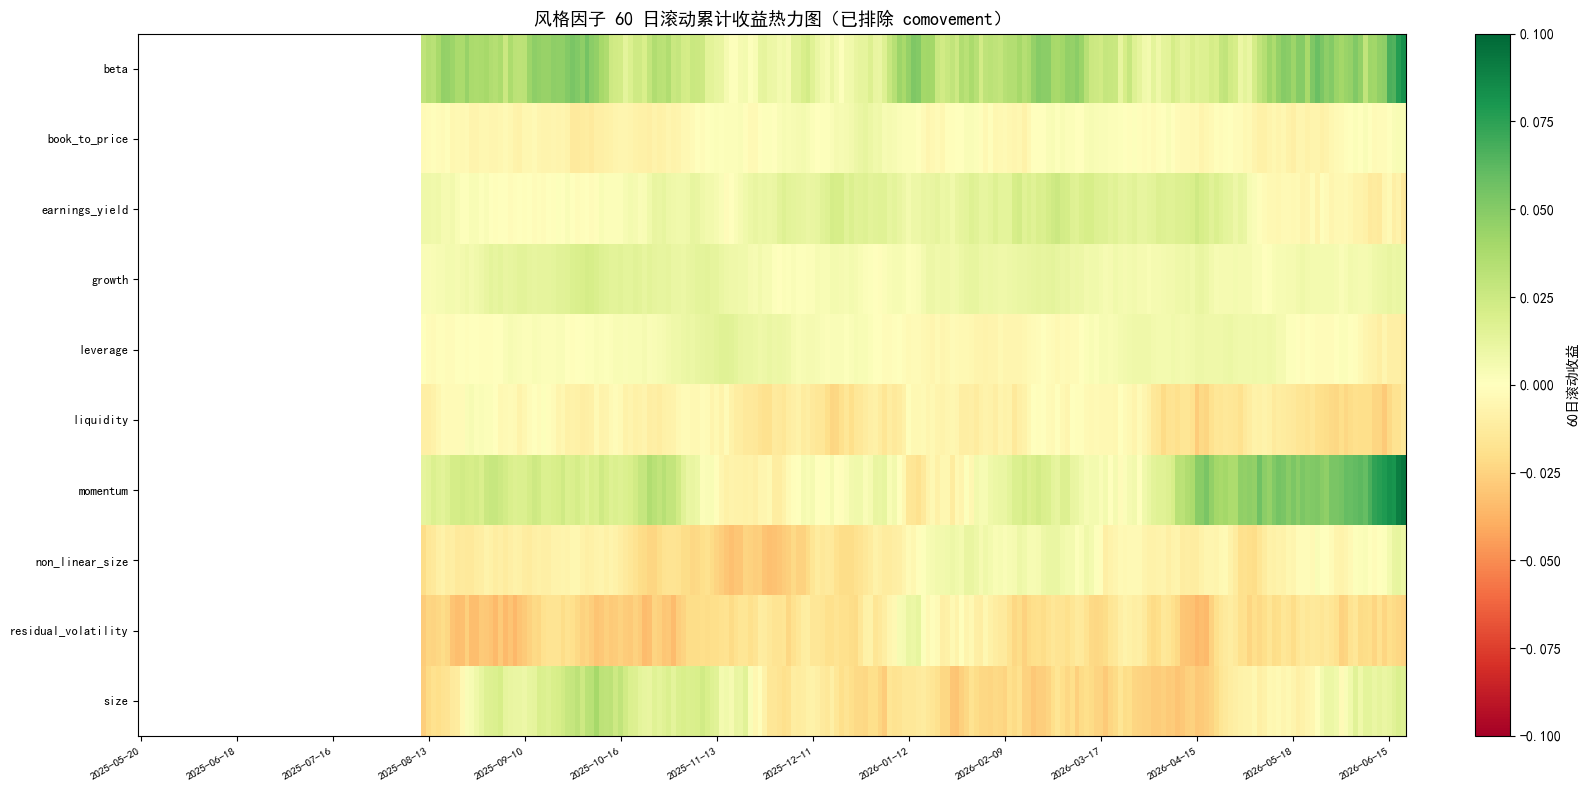

In [53]:
# ==================== Part 6：滚动窗口热力图 ====================
ROLLING_WINDOW = 60  # 约 12 周

# 同样排除 comovement（避免它的大幅波动压扁其他风格的颜色映射）
roll_factors = STYLE_V1_NO_COMM
roll_ret = fr_v1[roll_factors].rolling(ROLLING_WINDOW).apply(
    lambda x: np.exp(np.log1p(x).sum()) - 1  # 滚动累计收益
)

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(roll_ret.T.values, aspect='auto', cmap='RdYlGn',
               vmin=-0.10, vmax=0.10)  # ±10% 色域更清晰

ax.set_yticks(range(len(roll_factors)))
ax.set_yticklabels(roll_factors, fontsize=9)
ax.set_xticks(range(0, len(roll_ret), 20))
ax.set_xticklabels(roll_ret.index[::20].strftime('%Y-%m-%d'), rotation=30, ha='right', fontsize=8)
ax.set_title(f'风格因子 {ROLLING_WINDOW} 日滚动累计收益热力图（已排除 comovement）', fontsize=13, fontweight='bold')
fig.colorbar(im, ax=ax, fraction=0.03, label=f'{ROLLING_WINDOW}日滚动收益')
plt.tight_layout(); plt.show()

## Part 7 · 市场大盘参照

米筐模型中的 comovement 因子实际上承担了"市场大盘"的角色（暴露恒为 1，收益 = 全市场系统性上涨）。
不过我们在 Part 2~6 的风格趋势图中已经排除了它，所以这里单独画一下同期中证全指收益，
作为"comovement 到底贡献了多少"的直观佐证——两者形状应该非常相似。

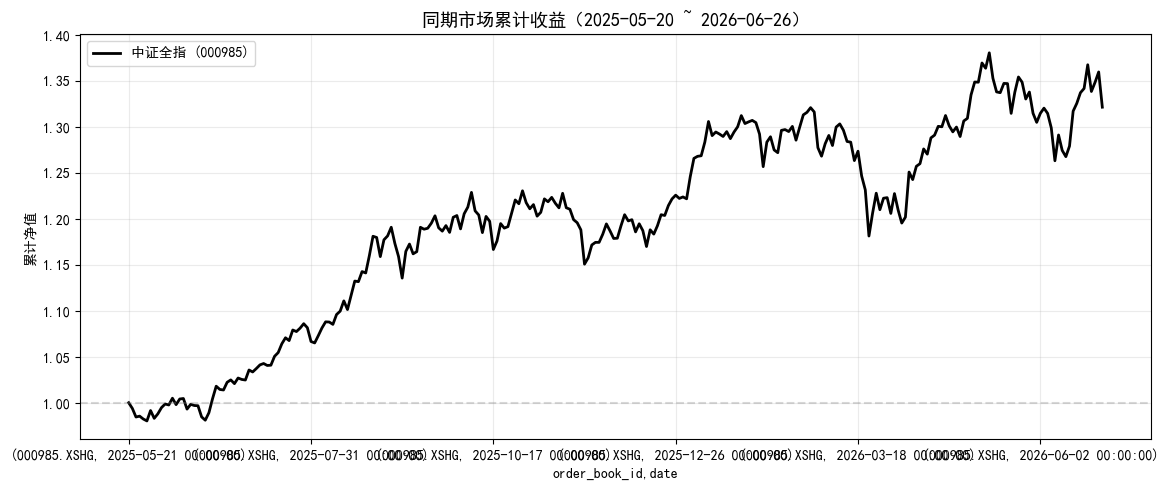

中证全指区间收益：32.15%
中证全指年化收益：27.78%


In [54]:
# ==================== Part 7：市场累计收益 ====================
# 获取同期中证全指（000985.XSHG）收益作为市场参考
mkt_px = rq.get_price('000985.XSHG', start_date=WINDOW_START, end_date=WINDOW_END,
                       frequency='1d', fields='close')
mkt_close = mkt_px['close']
if isinstance(mkt_close, pd.DataFrame):
    mkt_close = mkt_close.squeeze()
mkt_ret = mkt_close.pct_change().dropna()
mkt_cum = (1 + mkt_ret).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
mkt_cum.plot(ax=ax, linewidth=2, color='black', label='中证全指 (000985)')
ax.axhline(1, color='gray', ls='--', alpha=0.3)
ax.set_title(f'同期市场累计收益（{WINDOW_START} ~ {WINDOW_END}）', fontsize=13, fontweight='bold')
ax.set_ylabel('累计净值'); ax.grid(True, alpha=0.25)
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

print(f'中证全指区间收益：{mkt_cum.iloc[-1]-1:.2%}')
print(f'中证全指年化收益：{mkt_ret.mean()*252:.2%}')

---
## 总结

### 本 notebook 做了什么

1. **直接调米筐 API** `get_factor_return()` 拿官方因子收益，无需自己算截面回归
2. **按因子大类分组画图**：规模/价值/成长/动量/流动性/风险/杠杆/协同/质量... 一眼看市场风格趋势
3. **v1 vs v2 双模型**：v2 增加了质量/股息/反转等更丰富的角度
4. **与自建 Barra CNE5 对比**：逐因子叠加曲线 + 时间序列相关性 + 热图
5. **行业因子**与**滚动窗口**补充分析

### 在实盘中的用途

- **风格监控**：定期（每月）拉取最新因子收益，看风格趋势是否切换
- **主动暴露检查**：如果你的策略在某风格上有显著暴露（如超配小盘/低估值），
  你可以看到这个风格的收益趋势是否还在延续——如果动量因子已经连续 3 个月为负，
  你的趋势策略可能需要警惕风格反转
- **与自建模型对照**：发现长时间持续偏离（>0.2 累计收益差）时，排查自建构建口径是否需要调整

> 提示：本 notebook 的风格大类映射可以根据你自己的分析需求进行调整。
> 比如可以把 `size` + `mid_cap` + `non_linear_size` 一起看做"市值维度"，
> 也可以把 `book_to_price` + `earnings_yield` + `dividend_yield` 一起看做"估值维度"。

In [55]:
# ==================== 附录：导出自建 Barra CNE5 数据 ====================
# 运行条件：先跑完 barra_cne5_风格归因.ipynb 的 Part 1~4
# 然后在本 cell 把 style_ret 保存到 saved_data/

try:
    _export_path = os.path.join(SAVE_DIR, 'self_built_style_ret.parquet')
    style_ret.to_parquet(_export_path)
    print(f'自建 Barra CNE5 因子收益已保存到: {_export_path}')
    print(f'数据形状: {style_ret.shape}')
except NameError:
    print('当前会话无 style_ret 变量。请先运行 barra_cne5_风格归因.ipynb 的 Part 1~4。')
except Exception as e:
    print(f'导出失败: {e}')

当前会话无 style_ret 变量。请先运行 barra_cne5_风格归因.ipynb 的 Part 1~4。


### 附录 · 导出自建 Barra CNE5 数据

如果你想与本 notebook 做**官方 vs 自建**的对比，先运行 `barra_cne5_风格归因.ipynb` 的 Part 1~4
（确保内存中有 `style_ret` 变量），再运行下面的代码块把它存到 `saved_data/` 目录。
之后每次打开本 notebook，Part 4 会自动从文件加载自建数据。